## 一、前置準備

### 連動colab

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 是否使用GPU

In [ ]:
import torch

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Using {device} device')

Using cpu device


### 準備套件

In [ ]:
import pandas as pd

### Path

In [ ]:
cloud_path = '/content/drive/My Drive/Colab Notebooks'
to_path = '/content/drive/My Drive/Data'

### 下載訓練資料

In [ ]:
df = pd.read_csv('{}/{}'.format(to_path,'heart_cleveland_upload.csv'))
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


## 二、探索式資料分析EDA

### 分類變數

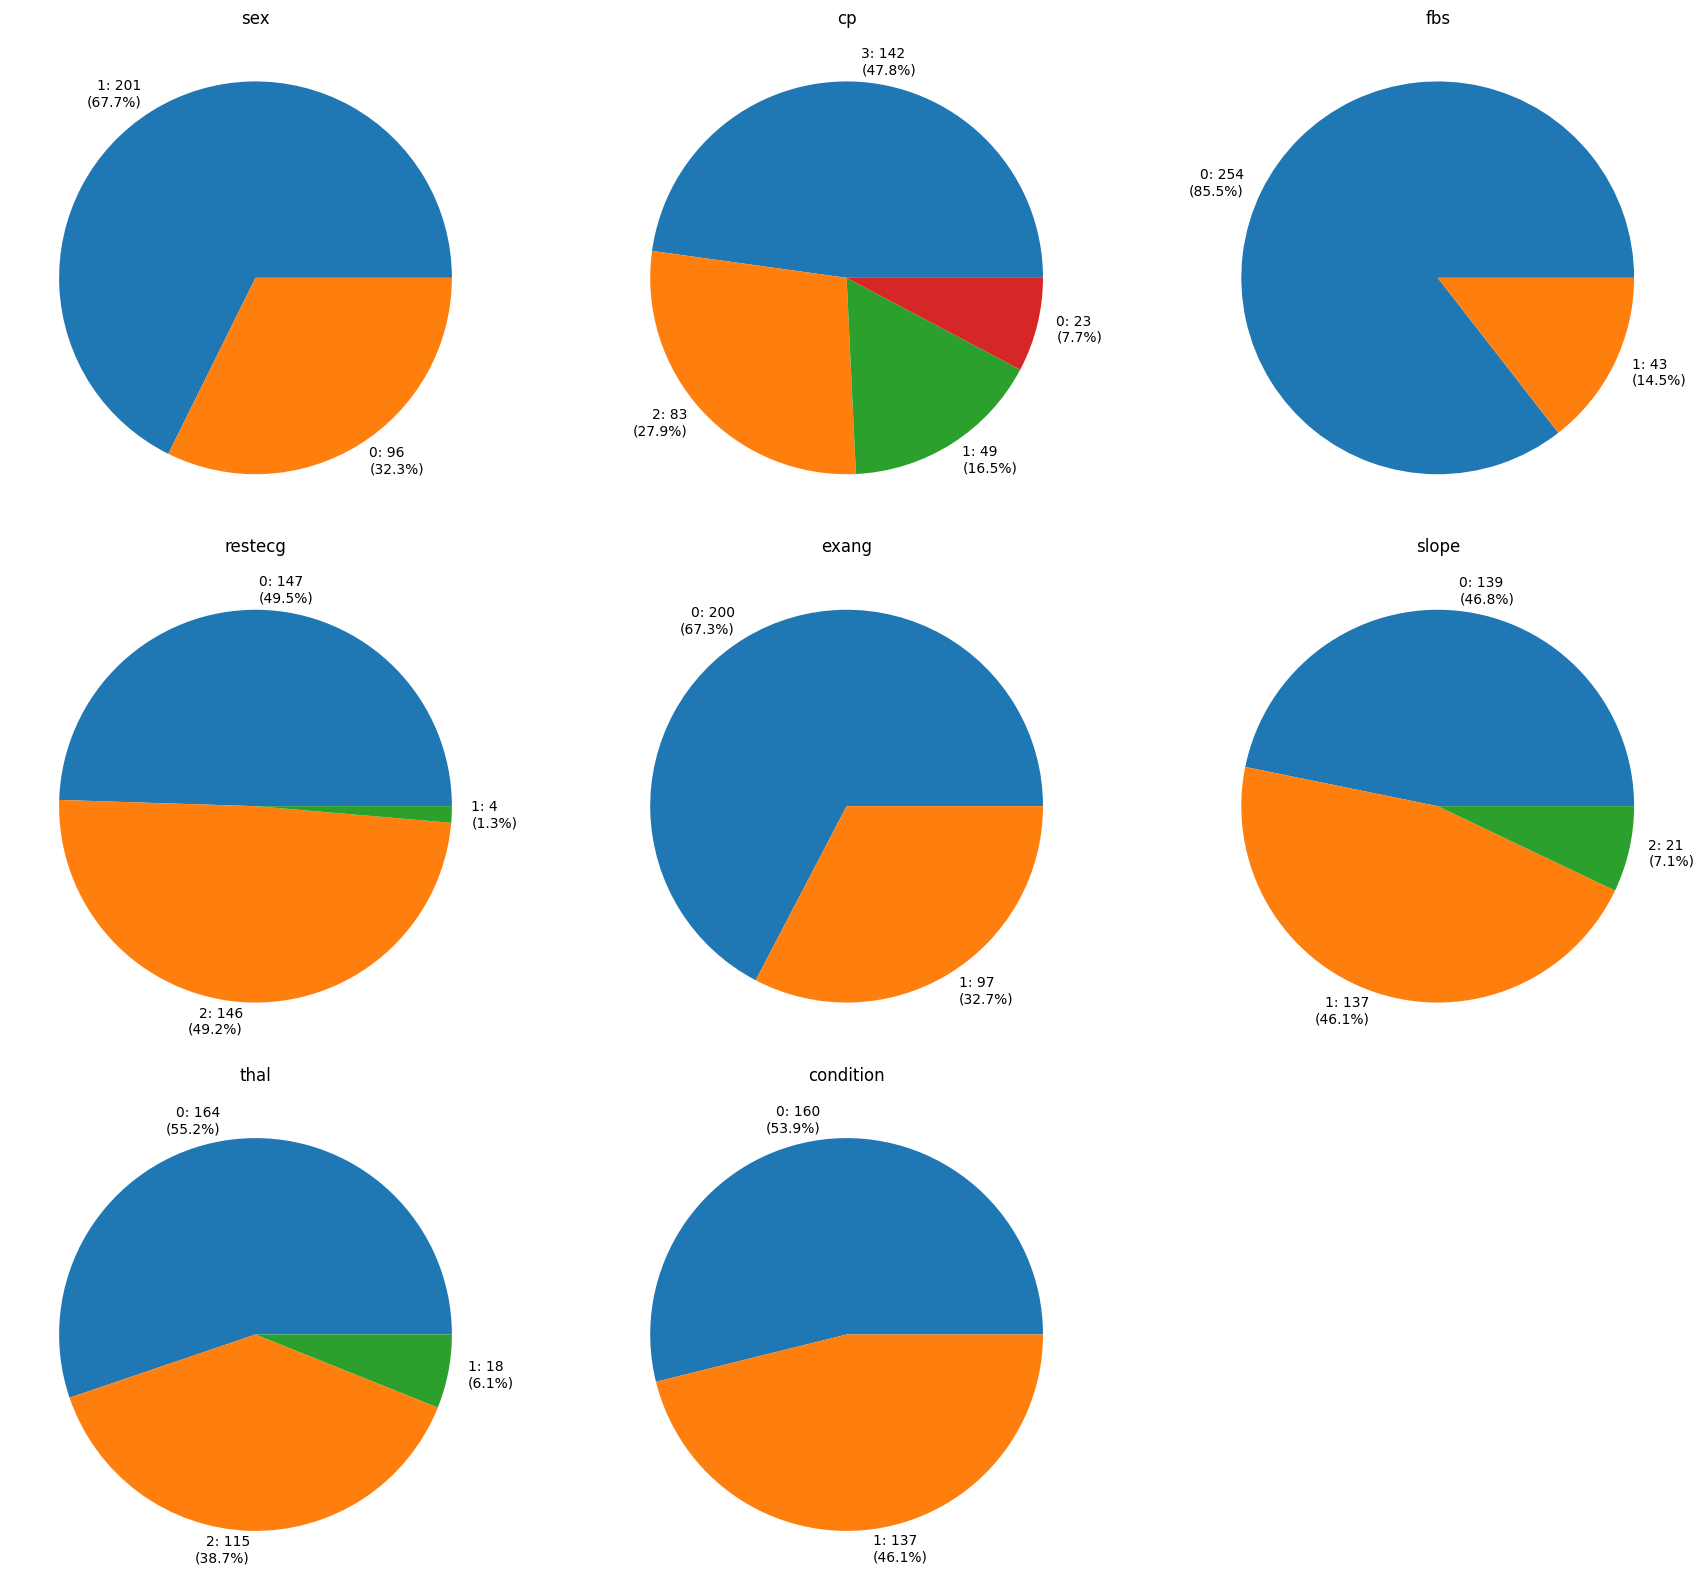

In [ ]:
# 選擇第2、4、10列的分類變數
cols_categorical = df.iloc[:, [1, 2, 5, 6, 8, 10, 12, 13]].columns

# 建立3x3分區
fig, axes = plt.subplots(3, 3, figsize=(18, 16))
# 將axes轉換為一維數組
axes = axes.flatten()

# 繪製每個分類變數的圓餅圖
for ax, col in zip(axes, cols_categorical):
    value_counts = df[col].value_counts()   # 統計每個分類的頻率
    labels = [f'{label}: {count}\n({count/sum(value_counts.values)*100:.1f}%)'
              for label, count in zip(value_counts.index, value_counts.values)]   # 定義標籤格式，包含類別名稱、數量和百分比
    # 繪製圓餅圖
    ax.pie(value_counts.values, labels=labels, autopct=None)
    ax.set_title(f'{col}')

# 如果有多餘區域，隱藏它們
for i in range(len(cols_categorical), len(axes)):
    fig.delaxes(axes[i])

# 調整佈局
plt.tight_layout()
plt.show()


### 連續變數

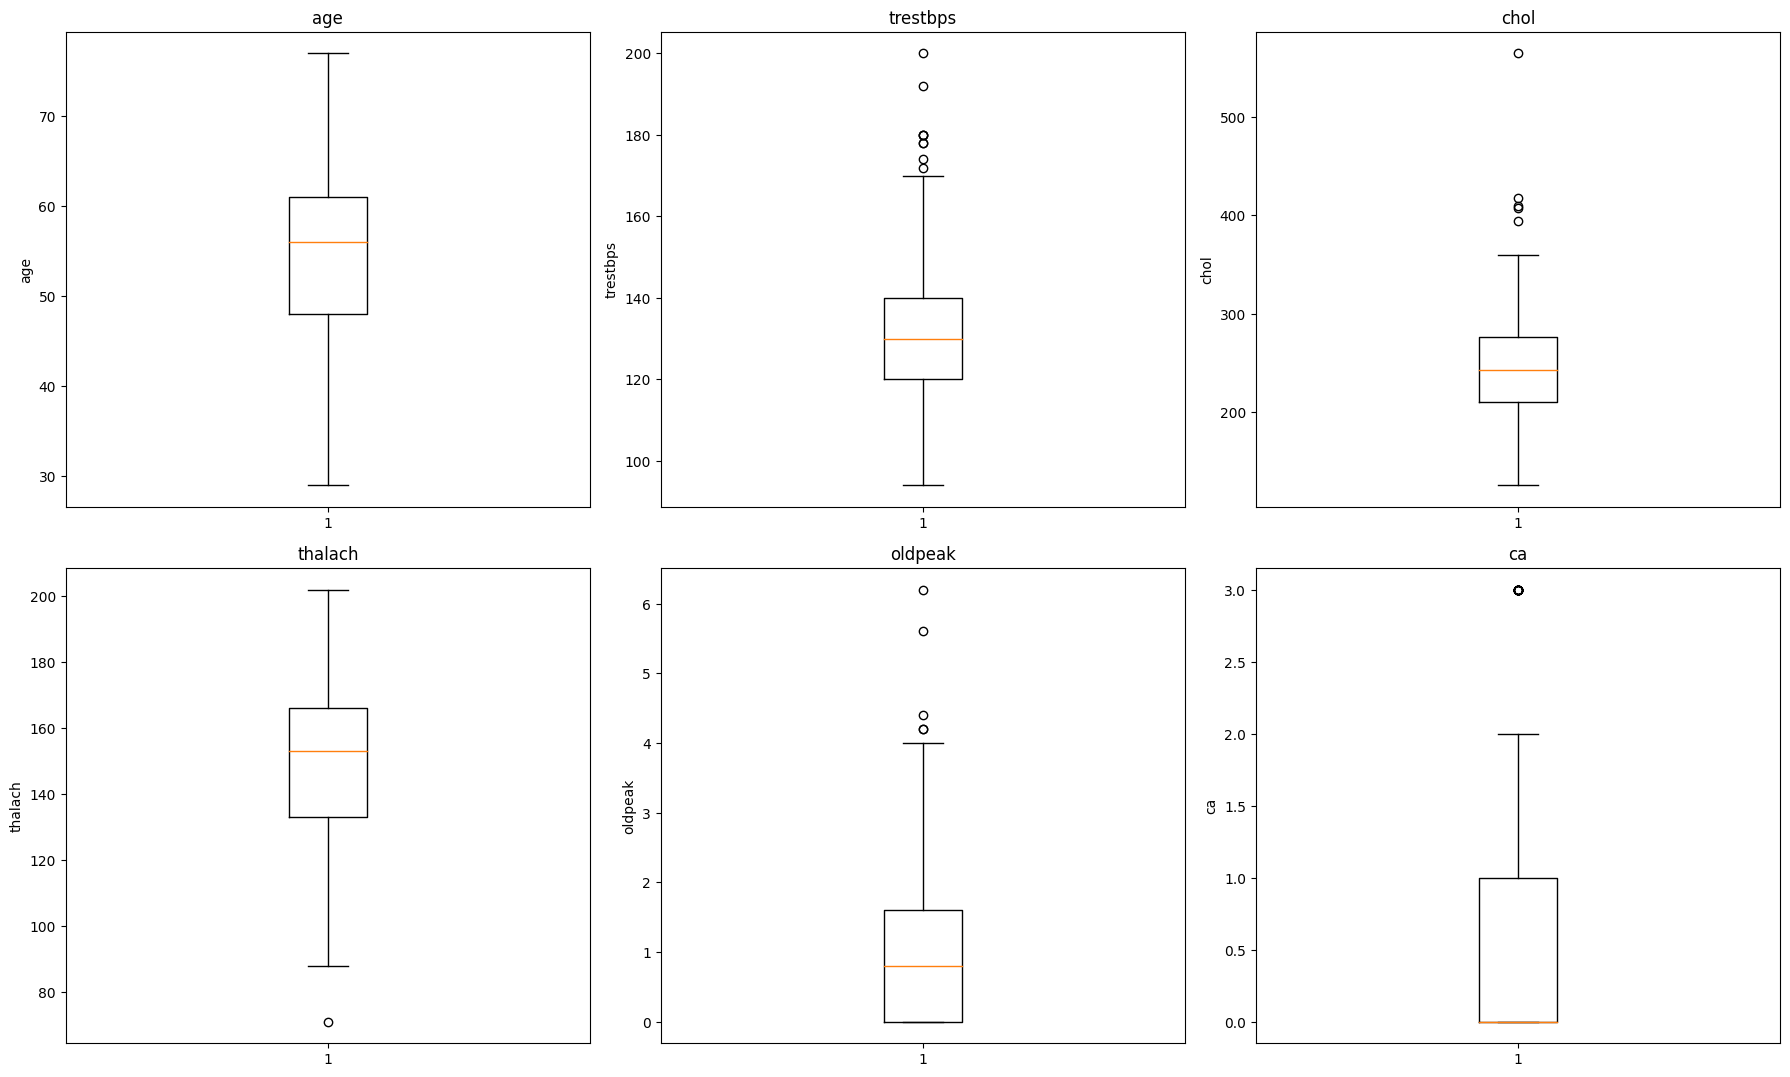

In [ ]:
# 選擇第2、4、10等列的連續變數
cols_numerical = df.iloc[:, [0, 3, 4, 7, 9, 11]].columns

# 建立3x3分區
fig, axes = plt.subplots(3, 3, figsize=(18, 16))
# 將axes轉換為一維數組
axes = axes.flatten()

# 繪製每個變數的盒形圖
for ax, col in zip(axes, cols_numerical):
# 繪製盒形圖
    ax.boxplot(df[col].dropna())  # 確保忽略缺失值
    ax.set_title(f'{col}')
    ax.set_ylabel(col)

# 如果有多餘區域，隱藏它們
for i in range(len(cols_numerical), len(axes)):
    fig.delaxes(axes[i])

# 調整佈局
plt.tight_layout()
plt.show()

### 熱力圖

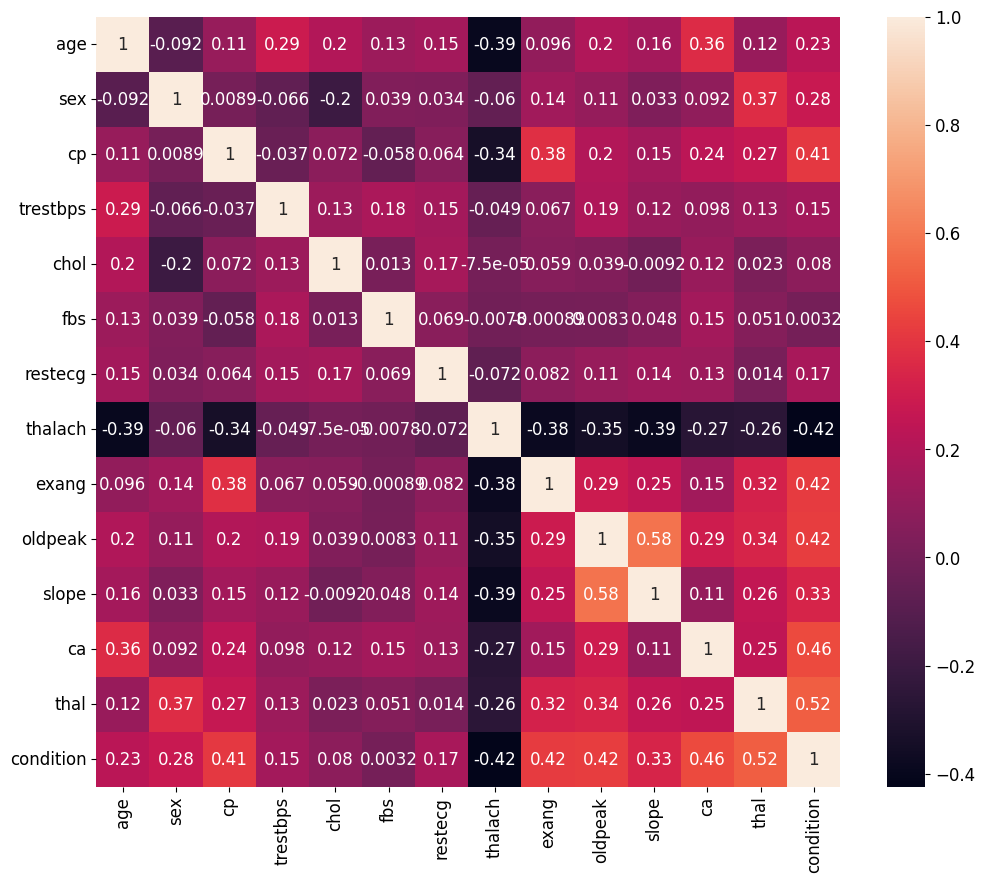

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 設置圖形大小
plt.figure(figsize=(12, 10))  # 調整為適合大小

cols_continuous = df.columns[:]
corr = df[cols_continuous].corr()

# 繪製熱圖
_ = sns.heatmap(corr, annot=True)

# 顯示圖形
plt.show()


## 三、資料前處理 : 標準化

In [ ]:
df.iloc[:, [0, 3, 4, 7, 9, 11]]

,age,trestbps,chol,thalach,oldpeak,ca
0,69,160,234,131,0.1,1
1,69,140,239,151,1.8,2
2,66,150,226,114,2.6,0
3,65,138,282,174,1.4,1
4,64,110,211,144,1.8,0
...,...,...,...,...,...,...
292,40,152,223,181,0.0,0
293,39,118,219,140,1.2,0
294,35,120,198,130,1.6,0
295,35,138,183,182,1.4,0


In [ ]:
from sklearn.preprocessing import StandardScaler

feature = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
scaler = StandardScaler()
df[feature] = scaler.fit_transform(df[feature])
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,1.600302,1,0,1.596266,-0.257179,1,2,-0.812095,0,-0.820813,1,0.344824,0,0
1,1.600302,0,0,0.468418,-0.160859,0,0,0.061157,0,0.639470,0,1.411625,0,0
2,1.268242,0,0,1.032342,-0.411292,0,0,-1.554358,0,1.326662,2,-0.721976,0,0
3,1.157555,1,0,0.355633,0.667499,1,2,1.065396,0,0.295874,1,0.344824,0,1
4,1.046868,1,0,-1.223355,-0.700254,0,2,-0.244481,1,0.639470,1,-0.721976,0,0


In [ ]:
df.iloc[:, [0, 3, 4, 7, 9, 11]]

,age,trestbps,chol,thalach,oldpeak,ca
0,1.600302,1.596266,-0.257179,-0.812095,-0.820813,0.344824
1,1.600302,0.468418,-0.160859,0.061157,0.639470,1.411625
2,1.268242,1.032342,-0.411292,-1.554358,1.326662,-0.721976
3,1.157555,0.355633,0.667499,1.065396,0.295874,0.344824
4,1.046868,-1.223355,-0.700254,-0.244481,0.639470,-0.721976
...,...,...,...,...,...,...
292,-1.609620,1.145127,-0.469085,1.371034,-0.906712,-0.721976
293,-1.720306,-0.772215,-0.546141,-0.419131,0.124076,-0.721976
294,-2.163054,-0.659431,-0.950688,-0.855757,0.467672,-0.721976
295,-2.163054,0.355633,-1.239649,1.414697,0.295874,-0.721976


## 四、劃分數據集

In [ ]:
%matplotlib inline
# 忽略警告
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# 去掉這y列，矩陣用X表示input
X = df.drop('condition',axis=1)

# y向量
y = df['condition']

In [ ]:
# 將資料分成訓練集和測試集,20%作為測試集，隨機數種子為10
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=10)

## 五、訓練與測試
(1)隨機森林   
(2)XGBoost   
(3)SVM    
評估指標:precision、recall、f1-score、ROC-AUC

## (1) 隨機森林

## 訓練

In [ ]:
# 建立隨機森林分類模型
from sklearn.ensemble import RandomForestClassifier
# 最大深度為5，決策樹為100，隨機種子數為5
model = RandomForestClassifier(max_depth=10,n_estimators=200,random_state=5)
# fit 擬合
model.fit(X_train,y_train)
# 查看第7個決策樹
estimator = model.estimators_[7]

## 視覺化

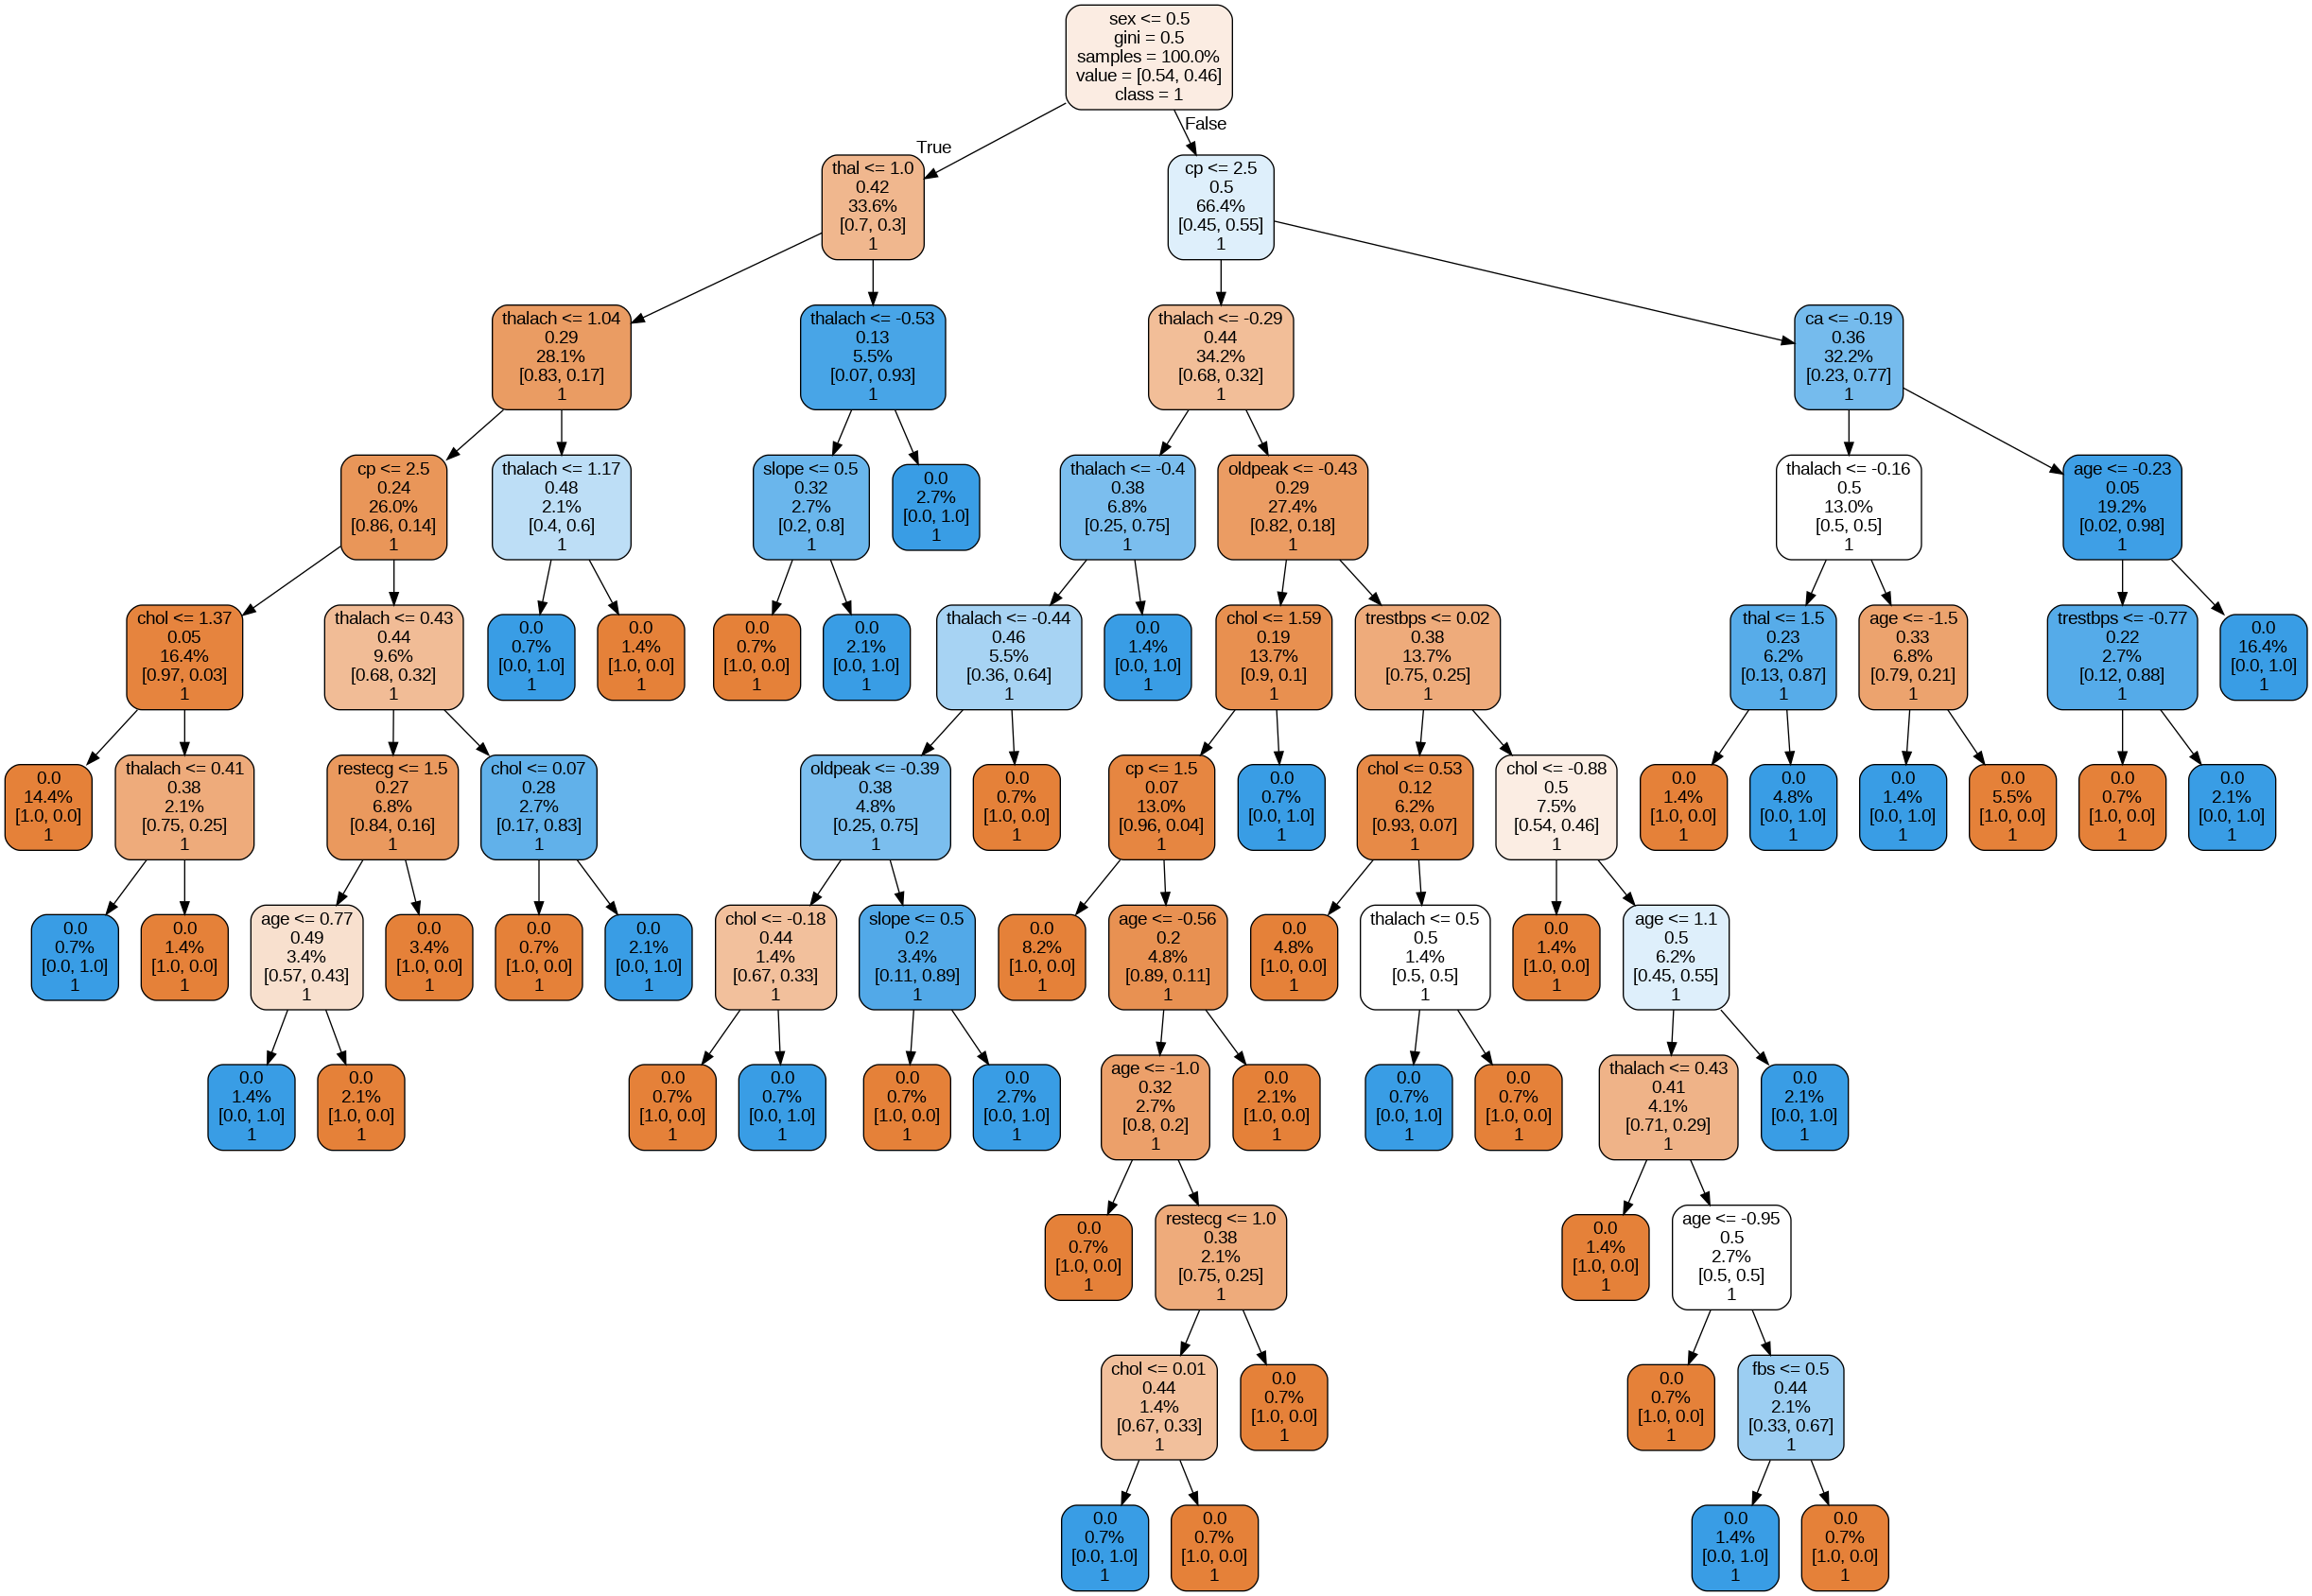

In [ ]:
import os
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import export_graphviz
import pydot
from IPython.display import Image, display

# 將輸出特徵值轉為字串
feature_names = X_train.columns
y_train_str = y_train.astype('str')
y_train_str[y_train=='0'] = 'no disease'
y_train_str[y_train=='1'] = 'disease'
y_train_str = y_train_str.values

to_path = '/content/drive/My Drive/'
# 匯出決策樹為 .dot 文件
export_graphviz(estimator,out_file='{}/{}'.format(to_path, 'tree.dot'),
                feature_names = feature_names,
                class_names = y_train_str,
                rounded = True,proportion = True,
                label='root',
                precision = 2,filled = True)

# 使用 pydot 產生 .png 文件
(graph,) = pydot.graph_from_dot_file('{}/{}'.format(to_path, 'tree.dot'))
graph.write_png('{}/{}'.format(to_path, 'tree.png'))

# 顯示產生的圖片
display(Image(filename='{}/{}'.format(to_path, 'tree.png')))


## 預測

In [ ]:
import numpy as np

# 在資料表中提取出對應的資料。
X_test.iloc
# 篩選出某樣本
test_sample = X_test.iloc[2]
# 變成二維
test_sample = np.array(test_sample).reshape(1,-1)

In [ ]:
# 二分類分類結果
model.predict(test_sample)

array([0])

In [ ]:
# 二分類分類結果
model.predict_proba(test_sample)

array([[0.835, 0.165]])

In [ ]:
# 預測整個測試樣本

# 正確答案
print('正確答案：',np.array(y_test))
# 預測結果
y_pred = model.predict(X_test)
print('預測結果：',y_pred)
# 得到心臟病和不患心臟病的信賴區間
y_pred_proba = model.predict_proba(X_test)
# 只獲得心臟病的信賴區間
model.predict_proba(X_test)[:,1]

正確答案： [0 0 0 0 1 0 1 1 1 1 1 0 1 0 1 1 0 1 0 1 1 1 0 0 1 0 1 1 0 0 0 1 0 1 0 0 0
 0 0 0 1 0 0 1 0 1 0 0 0 1 1 1 0 1 0 0 1 0 0 1]
預測結果： [0 0 0 0 1 0 1 0 0 1 1 0 1 0 1 1 0 1 0 1 0 1 0 0 1 0 1 1 0 0 0 0 0 1 0 0 1
 0 0 0 1 0 0 1 1 1 0 0 0 0 1 1 1 1 0 1 1 0 0 0]


array([0.185     , 0.025     , 0.165     , 0.27      , 0.93      ,
       0.05      , 0.96      , 0.305     , 0.430625  , 0.64      ,
       0.91      , 0.23      , 0.555     , 0.2       , 0.9       ,
       0.525     , 0.115     , 0.785     , 0.02840909, 0.835     ,
       0.235     , 0.84      , 0.475     , 0.195     , 0.6575    ,
       0.09229167, 0.835     , 0.985     , 0.22      , 0.19166667,
       0.3045    , 0.357     , 0.34057143, 0.6475    , 0.222     ,
       0.24333333, 0.83      , 0.275625  , 0.29027778, 0.11875   ,
       0.55125   , 0.025     , 0.415     , 0.7525    , 0.66      ,
       1.        , 0.125     , 0.46      , 0.075     , 0.295     ,
       0.67666667, 0.87      , 0.54666667, 0.82875   , 0.2925    ,
       0.591875  , 0.68      , 0.225     , 0.095     , 0.3825    ])

## 混淆矩阵

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix_model = confusion_matrix(y_test, y_pred)

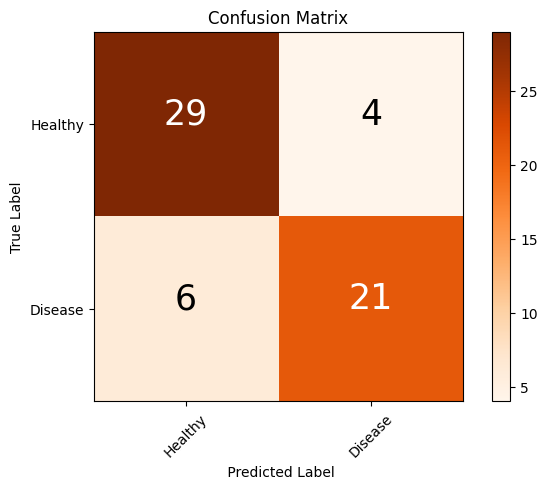

In [ ]:
# 將混淆矩陣繪製出來
import matplotlib.pyplot as plt
import itertools
def cnf_matrix_plotter(cm,classes):
    '''
    傳入混淆矩陣和標籤名稱列表，繪製混淆矩陣
    '''
    # plt.imshow (cm, interpolation='nearest', cmap=plt.cm.Greens)
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Oranges)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks,classes,rotation=45)
    plt.yticks(tick_marks,classes)

    threshold = cm.max() / 2.
    for i, j in itertools.product(range(cm. shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i,j],
        horizontalalignment="center",
        color="white" if cm[i,j] > threshold else "black",fontsize=25)
    plt.tight_layout()
    plt.ylabel('True Label')
    plt.xlabel(' Predicted Label')
    plt.show()
cnf_matrix_plotter(confusion_matrix_model,['Healthy','Disease'])

## 評估指標

In [ ]:
# 計算準確度、召回率、f1分數
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred,target_names=['Healthy', 'Disease']))

              precision    recall  f1-score   support

     Healthy       0.83      0.88      0.85        33
     Disease       0.84      0.78      0.81        27

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60



## ROC、AUC

0.9191919191919191

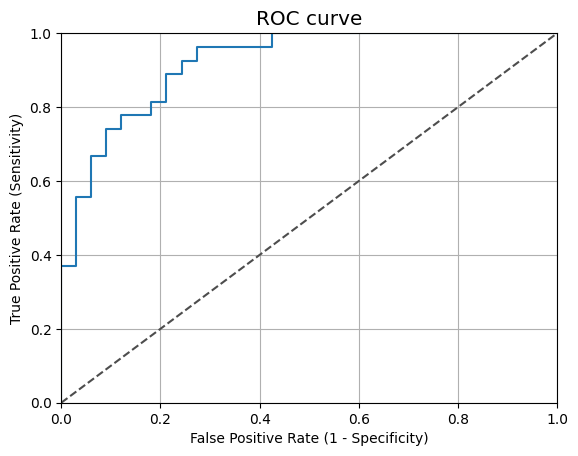

In [ ]:
# ROC曲线
y_pred_quant = model.predict_proba(X_test)[:,1]
from sklearn. metrics import roc_curve,auc
fpr,tpr,thresholds = roc_curve(y_test,y_pred_quant)
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],ls="--",c=".3")
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.0])
plt.rcParams['font.size'] = 12
plt.title('ROC curve')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.grid(True)

# 計算AUC曲線
auc(fpr,tpr)

## (2) XGBoost

## 訓練

In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)

model.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

## 預測

In [ ]:

print('正確答案：',np.array(y_test))

y_pred = model.predict(X_test)
print('預測結果：',y_pred)

y_pred_proba = model.predict_proba(X_test)

model.predict_proba(X_test)[:,1]

正確答案： [0 0 0 0 1 0 1 1 1 1 1 0 1 0 1 1 0 1 0 1 1 1 0 0 1 0 1 1 0 0 0 1 0 1 0 0 0
 0 0 0 1 0 0 1 0 1 0 0 0 1 1 1 0 1 0 0 1 0 0 1]
預測結果： [0 0 0 0 1 0 1 0 0 0 1 0 1 0 1 1 0 1 0 1 0 1 0 0 1 0 1 1 0 0 0 0 0 0 0 0 1
 0 0 0 1 0 1 1 1 1 0 1 0 0 1 1 0 1 0 1 1 0 0 1]


array([6.03851210e-03, 1.52665525e-04, 4.27305363e-02, 2.38961339e-01,
       9.96544778e-01, 4.58987313e-04, 9.99448836e-01, 8.50091502e-02,
       1.24859624e-01, 2.33743057e-01, 9.99345720e-01, 1.58210441e-01,
       8.70133400e-01, 7.40890950e-03, 9.99501705e-01, 5.05690813e-01,
       3.17542702e-02, 9.99469340e-01, 3.04535468e-04, 9.88447607e-01,
       3.08194514e-02, 9.97795939e-01, 2.25130856e-01, 1.23485923e-01,
       9.86207843e-01, 2.85464968e-03, 9.86739635e-01, 9.99721706e-01,
       9.49444436e-03, 2.65278388e-02, 1.06124505e-01, 7.54195228e-02,
       2.24569380e-01, 2.60972410e-01, 6.23525158e-02, 6.17688410e-02,
       9.48348999e-01, 1.16458133e-01, 2.39872355e-02, 1.17552811e-02,
       9.22866762e-01, 8.03079529e-05, 8.63897324e-01, 9.83525872e-01,
       8.50429177e-01, 9.99920249e-01, 3.92656715e-04, 9.42367315e-01,
       3.41070676e-03, 3.53974998e-01, 9.87267792e-01, 9.87424314e-01,
       3.23735595e-01, 9.92023349e-01, 9.70953852e-02, 9.98375416e-01,
      

## 混淆矩陣

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix_model = confusion_matrix(y_test, y_pred)

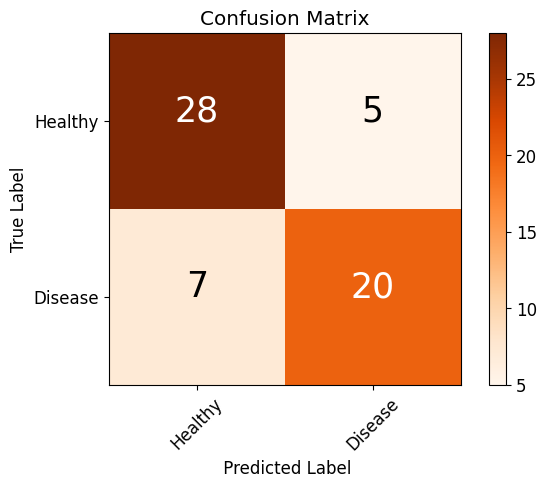

In [ ]:
import matplotlib.pyplot as plt
import itertools
def cnf_matrix_plotter(cm,classes):
    # plt.imshow (cm, interpolation='nearest', cmap=plt.cm.Greens)
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Oranges)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks,classes,rotation=45)
    plt.yticks(tick_marks,classes)

    threshold = cm.max() / 2.
    for i, j in itertools.product(range(cm. shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i,j],
        horizontalalignment="center",
        color="white" if cm[i,j] > threshold else "black",fontsize=25)
    plt.tight_layout()
    plt.ylabel('True Label')
    plt.xlabel(' Predicted Label')
    plt.show()
cnf_matrix_plotter(confusion_matrix_model,['Healthy','Disease'])

## 評估指標

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred,target_names=['Healthy', 'Disease']))

              precision    recall  f1-score   support

     Healthy       0.80      0.85      0.82        33
     Disease       0.80      0.74      0.77        27

    accuracy                           0.80        60
   macro avg       0.80      0.79      0.80        60
weighted avg       0.80      0.80      0.80        60



## ROC、AUC

0.8900112233445566

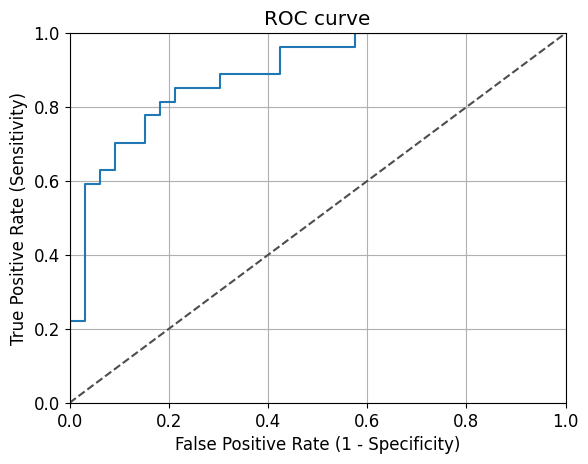

In [ ]:
y_pred_quant = model.predict_proba(X_test)[:,1]
from sklearn. metrics import roc_curve,auc
fpr,tpr,thresholds = roc_curve(y_test,y_pred_quant)
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],ls="--",c=".3")
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.0])
plt.rcParams['font.size'] = 12
plt.title('ROC curve')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.grid(True)

auc(fpr,tpr)

## (3) SVM

In [ ]:
from sklearn.svm import SVC

model = SVC(kernel='linear', C=1.0, probability=True)

model.fit(X_train,y_train)

SVC(kernel='linear', probability=True)

## 預測

In [ ]:
import numpy as np

X_test.iloc
test_sample = X_test.iloc[2]
test_sample = np.array(test_sample).reshape(1,-1)

In [ ]:
model.predict(test_sample)

array([0])

In [ ]:
model.predict_proba(test_sample)

array([[0.85091582, 0.14908418]])

In [ ]:
print('正確答案：',np.array(y_test))

y_pred = model.predict(X_test)
print('預測結果：',y_pred)

y_pred_proba = model.predict_proba(X_test)

model.predict_proba(X_test)[:,1]

正確答案： [0 0 0 0 1 0 1 1 1 1 1 0 1 0 1 1 0 1 0 1 1 1 0 0 1 0 1 1 0 0 0 1 0 1 0 0 0
 0 0 0 1 0 0 1 0 1 0 0 0 1 1 1 0 1 0 0 1 0 0 1]
預測結果： [0 0 0 0 1 0 1 1 1 1 1 0 1 0 1 1 0 1 0 1 0 1 0 0 1 0 1 1 0 0 0 1 0 1 0 1 1
 0 0 0 1 0 0 1 1 1 0 1 0 0 1 1 1 1 0 0 1 0 0 0]


array([0.28632499, 0.08055264, 0.14908418, 0.22781552, 0.8115885 ,
       0.20420367, 0.93230839, 0.81493162, 0.51515888, 0.71061889,
       0.93002892, 0.20881626, 0.87848481, 0.22231646, 0.93293133,
       0.90566249, 0.07316289, 0.95170011, 0.13798894, 0.8646576 ,
       0.21908297, 0.98855592, 0.21608303, 0.39459754, 0.88123617,
       0.2026954 , 0.87637431, 0.97035566, 0.22193223, 0.35137192,
       0.23118139, 0.571432  , 0.16425865, 0.78238503, 0.36444949,
       0.59026634, 0.8608641 , 0.22762303, 0.19373874, 0.16389274,
       0.78839371, 0.03707742, 0.37836997, 0.91479262, 0.61482114,
       0.97539704, 0.06166704, 0.5588925 , 0.06082691, 0.29889136,
       0.68296124, 0.97499542, 0.56214387, 0.85366247, 0.11590585,
       0.29941318, 0.73349825, 0.20435961, 0.05951838, 0.25033848])

## 混淆矩陣

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix_model = confusion_matrix(y_test, y_pred)

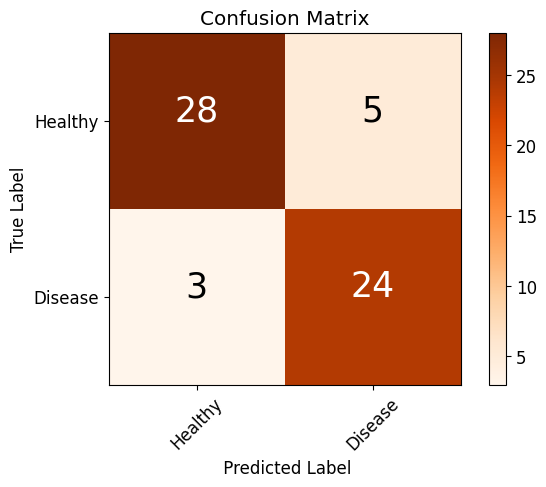

In [ ]:
import matplotlib.pyplot as plt
import itertools
def cnf_matrix_plotter(cm,classes):
    # plt.imshow (cm, interpolation='nearest', cmap=plt.cm.Greens)
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Oranges)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks,classes,rotation=45)
    plt.yticks(tick_marks,classes)

    threshold = cm.max() / 2.
    for i, j in itertools.product(range(cm. shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i,j],
        horizontalalignment="center",
        color="white" if cm[i,j] > threshold else "black",fontsize=25)
    plt.tight_layout()
    plt.ylabel('True Label')
    plt.xlabel(' Predicted Label')
    plt.show()
cnf_matrix_plotter(confusion_matrix_model,['Healthy','Disease'])

## 評估指標

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred,target_names=['Healthy', 'Disease']))

              precision    recall  f1-score   support

     Healthy       0.90      0.85      0.88        33
     Disease       0.83      0.89      0.86        27

    accuracy                           0.87        60
   macro avg       0.87      0.87      0.87        60
weighted avg       0.87      0.87      0.87        60



## ROC、AUC

0.9405162738496071

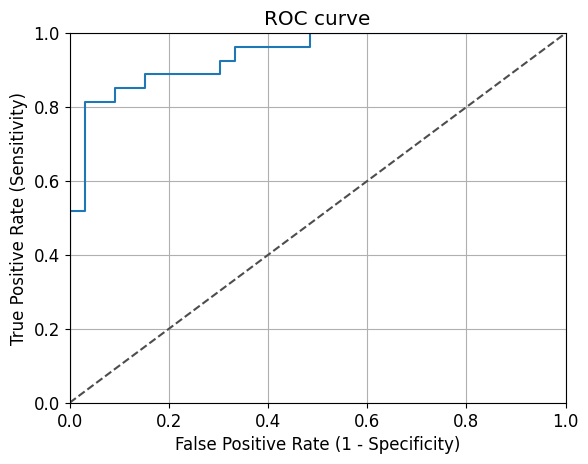

In [ ]:
y_pred_quant = model.predict_proba(X_test)[:,1]
from sklearn. metrics import roc_curve,auc
fpr,tpr,thresholds = roc_curve(y_test,y_pred_quant)
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],ls="--",c=".3")
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.0])
plt.rcParams['font.size'] = 12
plt.title('ROC curve')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.grid(True)

auc(fpr,tpr)